<a href="https://www.kaggle.com/code/oladayofolasire/mental-health-in-tech-modelling?scriptVersionId=308885718" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Import packages for data manipulation
# Import relevant libraries and modules.

import numpy as np
import pandas as pd

# This is the classifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance 
from xgboost import plot_importance

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)


# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv


In [2]:
# Read in data
file = '/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv'
df0 = pd.read_csv(file)
df0.head(10)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,No,Yes,Yes,Not sure,No,Don't know,Don't know,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,Yes,Yes,No,No,No,No,No,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,Yes,Yes,No,Yes,No,No,Yes,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,No,Yes,Yes,Yes,No,No,No,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,No,Yes,Don't know,No,Don't know,Don't know,Don't know,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


In [3]:
df0.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [4]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [5]:
df0.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

In [6]:
df0.shape

(1259, 27)

In [7]:
df0.size

33993

In [8]:
# Check value counts for all columns
for col in df0.columns:
    print(f"\n{col} value counts:")
    print(df0[col].value_counts(dropna=False))

# Extract year from Timestamp
df0['year'] = pd.to_datetime(df0['Timestamp'], errors='coerce').dt.year


Timestamp value counts:
Timestamp
2014-08-27 12:31:41    2
2014-08-28 16:52:34    2
2014-08-27 17:33:52    2
2014-08-27 12:54:11    2
2014-08-27 15:55:07    2
                      ..
2014-08-27 15:34:31    1
2014-08-27 15:34:23    1
2014-08-27 15:32:43    1
2014-08-27 15:32:19    1
2014-08-27 15:36:41    1
Name: count, Length: 1246, dtype: int64

Age value counts:
Age
 29             85
 32             82
 26             75
 27             71
 33             70
 28             68
 31             67
 34             65
 30             63
 25             61
 35             55
 23             51
 24             46
 37             43
 38             39
 36             37
 39             33
 40             33
 43             28
 41             21
 22             21
 42             20
 21             16
 45             12
 46             12
 44             11
 19              9
 18              7
 50              6
 48              6
 20              6
 51              5
 56              4


In [9]:
df0.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,year
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,2014
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN,2014
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN,2014
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN,2014
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN,2014


In [10]:
##Filters out invalid ages, standardizes gender into male, female, other, fills missing values in key categorical columns with Unknown, and drops mostly empty or irrelevant columns (comments, Timestamp) to clean and prep the dataset for modeling.##

In [11]:
# Clean Age
df0 = df0[(df0['Age'] > 15) & (df0['Age'] < 100)]

# Standardize Gender
df0['Gender'] = df0['Gender'].str.lower().replace({
    'm':'male','f':'female','man':'male','woman':'female','cis male':'male','cis female':'female',
    'male-ish':'male','female (cis)':'female'
})
df0['Gender'] = df0['Gender'].where(df0['Gender'].isin(['male','female']), 'other')

# Fill missing values for categorical columns
cat_cols = ['state','self_employed','work_interfere']
df0[cat_cols] = df0[cat_cols].fillna('Unknown')

# Drop comments
df0 = df0.drop(columns=['comments','Timestamp'])

In [12]:
df0.head()

,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,year
0,37,female,United States,IL,Unknown,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,2014
1,44,male,United States,IN,Unknown,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,2014
2,32,male,Canada,Unknown,Unknown,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,2014
3,31,male,United Kingdom,Unknown,Unknown,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,2014
4,31,male,United States,TX,Unknown,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,2014


In [13]:
df0.columns

Index(['Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'year'],
      dtype='object')

In [14]:
df0.dtypes

Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
year                          int32
dtype: object

In [15]:
# Select all object columns (strings)
cat_cols = df0.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col} categories and counts:")
    print(df0[col].value_counts(dropna=False))


Gender categories and counts:
Gender
male      972
female    242
other      37
Name: count, dtype: int64

Country categories and counts:
Country
United States             746
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Italy                       7
Switzerland                 7
Poland                      7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Singapore                   4
Bulgaria                    4
Russia                      3
Mexico                      3
Finland                     3
Austria                     3
Portugal                    2
Colombia                    2
Denmark                     2
Croatia                     2
Greece        

In [16]:

# Binary mapping
binary_cols = ['treatment','family_history','remote_work','tech_company','self_employed','obs_consequence']
for col in binary_cols:
    df0[col] = df0[col].map({'Yes':1,'No':0,'Unknown':0})  # Unknown mapped to 0

# Combine rare categories in Country and state
for col in ['Country','state']:
    counts = df0[col].value_counts()
    rare = counts[counts < 10].index
    df0[col] = df0[col].replace(rare,'Other')

# One-hot encode categorical columns with >2 categories
multi_cat_cols = ['Gender','Country','state','work_interfere','benefits','care_options','wellness_program',
                  'seek_help','anonymity','leave','mental_health_consequence','phys_health_consequence',
                  'coworkers','supervisor','mental_health_interview','phys_health_interview','mental_vs_physical']

df0 = pd.get_dummies(df0, columns=multi_cat_cols, drop_first=True)

In [17]:
df0.head()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,year,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37,0,0,1,6-25,0,1,0,2014,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,False,False,False,False,True
1,44,0,0,0,More than 1000,0,0,0,2014,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False
2,32,0,0,0,6-25,0,1,0,2014,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True,True,False
3,31,0,1,1,26-100,0,1,1,2014,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True,True,False,True,False,True,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,True,False
4,31,0,0,0,100-500,1,1,0,2014,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False


In [18]:
# Convert all boolean columns to integer
bool_cols = df0.select_dtypes(include='bool').columns
df0[bool_cols] = df0[bool_cols].astype(int)

In [19]:
df0.head()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,year,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37,0,0,1,6-25,0,1,0,2014,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1
1,44,0,0,0,More than 1000,0,0,0,2014,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
2,32,0,0,0,6-25,0,1,0,2014,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0
3,31,0,1,1,26-100,0,1,1,2014,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0
4,31,0,0,0,100-500,1,1,0,2014,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0


In [20]:
df0.isna().sum()

Age                            0
self_employed                  0
family_history                 0
treatment                      0
no_employees                   0
                              ..
mental_health_interview_Yes    0
phys_health_interview_No       0
phys_health_interview_Yes      0
mental_vs_physical_No          0
mental_vs_physical_Yes         0
Length: 73, dtype: int64

In [21]:
df0.dtypes

Age                             int64
self_employed                   int64
family_history                  int64
treatment                       int64
no_employees                   object
                                ...  
mental_health_interview_Yes     int64
phys_health_interview_No        int64
phys_health_interview_Yes       int64
mental_vs_physical_No           int64
mental_vs_physical_Yes          int64
Length: 73, dtype: object

In [22]:
emp_map = {
    '1-5': 3,
    '6-25': 15,
    '26-100': 63,
    '100-500': 300,
    '500-1000': 750,
    'More than 1000': 1200
}
df0['no_employees'] = df0['no_employees'].map(emp_map)

In [23]:
df0.dtypes

Age                            int64
self_employed                  int64
family_history                 int64
treatment                      int64
no_employees                   int64
                               ...  
mental_health_interview_Yes    int64
phys_health_interview_No       int64
phys_health_interview_Yes      int64
mental_vs_physical_No          int64
mental_vs_physical_Yes         int64
Length: 73, dtype: object

In [24]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1251 entries, 0 to 1258
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            1251 non-null   int64
 1   self_employed                  1251 non-null   int64
 2   family_history                 1251 non-null   int64
 3   treatment                      1251 non-null   int64
 4   no_employees                   1251 non-null   int64
 5   remote_work                    1251 non-null   int64
 6   tech_company                   1251 non-null   int64
 7   obs_consequence                1251 non-null   int64
 8   year                           1251 non-null   int32
 9   Gender_male                    1251 non-null   int64
 10  Gender_other                   1251 non-null   int64
 11  Country_Canada                 1251 non-null   int64
 12  Country_France                 1251 non-null   int64
 13  Country_Germany        

In [25]:
df0.shape

(1251, 73)

In [26]:
df0.columns

Index(['Age', 'self_employed', 'family_history', 'treatment', 'no_employees',
       'remote_work', 'tech_company', 'obs_consequence', 'year', 'Gender_male',
       'Gender_other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Ireland', 'Country_Netherlands',
       'Country_Other', 'Country_United Kingdom', 'Country_United States',
       'state_FL', 'state_GA', 'state_IL', 'state_IN', 'state_MA', 'state_MI',
       'state_MN', 'state_MO', 'state_NC', 'state_NY', 'state_OH', 'state_OR',
       'state_Other', 'state_PA', 'state_TN', 'state_TX', 'state_UT',
       'state_Unknown', 'state_VA', 'state_WA', 'state_WI',
       'work_interfere_Often', 'work_interfere_Rarely',
       'work_interfere_Sometimes', 'work_interfere_Unknown', 'benefits_No',
       'benefits_Yes', 'care_options_Not sure', 'care_options_Yes',
       'wellness_program_No', 'wellness_program_Yes', 'seek_help_No',
       'seek_help_Yes', 'anonymity_No', 'anonymity_Yes',
       '

In [27]:
# List of reference dummy columns to drop (one from each category)
# Also dropping 'year' since it is not needed as a predictor
drop_columns = [
    'year',
    'Gender_other',                  
    'Country_United States',         
    'state_Unknown',                 
    'work_interfere_Unknown',        
    'benefits_No',                   
    'care_options_No',               
    'wellness_program_No',           
    'seek_help_No',                  
    'anonymity_No',                  
    'leave_Very difficult',          
    'mental_health_consequence_No',  
    'phys_health_consequence_No',    
    'coworkers_No',                  
    'supervisor_No',                 
    'mental_health_interview_No',    
    'phys_health_interview_No',      
    'mental_vs_physical_No'
]

# Keep only columns that actually exist in the dataframe
drop_columns_existing = [col for col in drop_columns if col in df0.columns]

# Drop selected columns
df_model = df0.drop(columns=drop_columns_existing)

# Define target variable
y = df_model['treatment']

# Define predictor variables
X = df_model.drop(columns=['treatment'])

# Check final shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1251, 57)
y shape: (1251,)


In [28]:
df0.columns

Index(['Age', 'self_employed', 'family_history', 'treatment', 'no_employees',
       'remote_work', 'tech_company', 'obs_consequence', 'year', 'Gender_male',
       'Gender_other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Ireland', 'Country_Netherlands',
       'Country_Other', 'Country_United Kingdom', 'Country_United States',
       'state_FL', 'state_GA', 'state_IL', 'state_IN', 'state_MA', 'state_MI',
       'state_MN', 'state_MO', 'state_NC', 'state_NY', 'state_OH', 'state_OR',
       'state_Other', 'state_PA', 'state_TN', 'state_TX', 'state_UT',
       'state_Unknown', 'state_VA', 'state_WA', 'state_WI',
       'work_interfere_Often', 'work_interfere_Rarely',
       'work_interfere_Sometimes', 'work_interfere_Unknown', 'benefits_No',
       'benefits_Yes', 'care_options_Not sure', 'care_options_Yes',
       'wellness_program_No', 'wellness_program_Yes', 'seek_help_No',
       'seek_help_Yes', 'anonymity_No', 'anonymity_Yes',
       '

In [29]:
df0 = df0.drop(columns=['year'], errors='ignore')

In [30]:
print(df0.columns)

Index(['Age', 'self_employed', 'family_history', 'treatment', 'no_employees',
       'remote_work', 'tech_company', 'obs_consequence', 'Gender_male',
       'Gender_other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Ireland', 'Country_Netherlands',
       'Country_Other', 'Country_United Kingdom', 'Country_United States',
       'state_FL', 'state_GA', 'state_IL', 'state_IN', 'state_MA', 'state_MI',
       'state_MN', 'state_MO', 'state_NC', 'state_NY', 'state_OH', 'state_OR',
       'state_Other', 'state_PA', 'state_TN', 'state_TX', 'state_UT',
       'state_Unknown', 'state_VA', 'state_WA', 'state_WI',
       'work_interfere_Often', 'work_interfere_Rarely',
       'work_interfere_Sometimes', 'work_interfere_Unknown', 'benefits_No',
       'benefits_Yes', 'care_options_Not sure', 'care_options_Yes',
       'wellness_program_No', 'wellness_program_Yes', 'seek_help_No',
       'seek_help_Yes', 'anonymity_No', 'anonymity_Yes',
       'leave_So

In [31]:
df0.head()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37,0,0,1,15,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1
1,44,0,0,0,1200,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
2,32,0,0,0,15,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0
3,31,0,1,1,63,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0
4,31,0,0,0,300,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0


In [32]:

# Split into train + temp (for validation/test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [33]:
df0.head()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37,0,0,1,15,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1
1,44,0,0,0,1200,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
2,32,0,0,0,15,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0
3,31,0,1,1,63,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0
4,31,0,0,0,300,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0


In [34]:
df0.columns

Index(['Age', 'self_employed', 'family_history', 'treatment', 'no_employees',
       'remote_work', 'tech_company', 'obs_consequence', 'Gender_male',
       'Gender_other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Ireland', 'Country_Netherlands',
       'Country_Other', 'Country_United Kingdom', 'Country_United States',
       'state_FL', 'state_GA', 'state_IL', 'state_IN', 'state_MA', 'state_MI',
       'state_MN', 'state_MO', 'state_NC', 'state_NY', 'state_OH', 'state_OR',
       'state_Other', 'state_PA', 'state_TN', 'state_TX', 'state_UT',
       'state_Unknown', 'state_VA', 'state_WA', 'state_WI',
       'work_interfere_Often', 'work_interfere_Rarely',
       'work_interfere_Sometimes', 'work_interfere_Unknown', 'benefits_No',
       'benefits_Yes', 'care_options_Not sure', 'care_options_Yes',
       'wellness_program_No', 'wellness_program_Yes', 'seek_help_No',
       'seek_help_Yes', 'anonymity_No', 'anonymity_Yes',
       'leave_So

In [35]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns
num_cols = ['Age', 'no_employees', 'self_employed', 'family_history', 'remote_work', 'tech_company', 'obs_consequence']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [36]:
df0.head()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37,0,0,1,15,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1
1,44,0,0,0,1200,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
2,32,0,0,0,15,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,1,0,1,0,1,1,0
3,31,0,1,1,63,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0
4,31,0,0,0,300,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0


In [37]:
df0.describe()

,Age,self_employed,family_history,treatment,no_employees,remote_work,tech_company,obs_consequence,Gender_male,Gender_other,Country_Canada,Country_France,Country_Germany,Country_India,Country_Ireland,Country_Netherlands,Country_Other,Country_United Kingdom,Country_United States,state_FL,state_GA,state_IL,state_IN,state_MA,state_MI,state_MN,state_MO,state_NC,state_NY,state_OH,state_OR,state_Other,state_PA,state_TN,state_TX,state_UT,state_Unknown,state_VA,state_WA,state_WI,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
count,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000
mean,32.076739,0.113509,0.390887,0.505196,365.829736,0.296563,0.819345,0.144684,0.776978,0.029576,0.057554,0.010392,0.035971,0.007994,0.021583,0.021583,0.084732,0.147082,0.596323,0.011990,0.009592,0.022382,0.021583,0.015987,0.017586,0.015987,0.009592,0.011191,0.045564,0.021583,0.023181,0.073541,0.023181,0.035971,0.035172,0.008793,0.410072,0.011191,0.055955,0.009592,0.111910,0.138289,0.370903,0.209432,0.296563,0.378098,0.250200,0.350919,0.669065,0.181455,0.512390,0.197442,0.051159,0.297362,0.099920,0.211831,0.077538,0.162270,0.389289,0.230216,0.735412,0.046363,0.616307,0.177458,0.278977,0.409273,0.801759,0.032774,0.396483,0.159872,0.270184,0.270983
std,7.288272,0.317341,0.488144,0.500173,479.938698,0.456925,0.384886,0.351923,0.416439,0.169483,0.232991,0.101449,0.186293,0.089085,0.145375,0.145375,0.278594,0.354330,0.490830,0.108886,0.097509,0.147982,0.145375,0.125476,0.131493,0.125476,0.097509,0.105236,0.208620,0.145375,0.150540,0.261127,0.150540,0.186293,0.184288,0.093395,0.492043,0.105236,0.229927,0.097509,0.315382,0.345341,0.483240,0.407066,0.456925,0.485106,0.433301,0.477449,0.470738,0.385549,0.500046,0.398228,0.220410,0.457280,0.300013,0.408769,0.267550,0.368846,0.487784,0.421139,0.441290,0.210354,0.486479,0.382209,0.448675,0.491896,0.398834,0.178115,0.489362,0.366634,0.444232,0.444645
min,18.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000

In [38]:
# Check mean and std of no_employees in train set
print("Mean:", X_train['no_employees'].mean())
print("Std:", X_train['no_employees'].std())

# Look at first few values
print(X_train['no_employees'].head())

Mean: 6.597896832058073e-17
Std: 1.000571918834288
1188   -0.649198
752    -0.161915
669    -0.161915
323     1.688525
870     1.688525
Name: no_employees, dtype: float64


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# -------------------------------
# 1️⃣ Define parameter grid
# -------------------------------
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

# -------------------------------
# 2️⃣ Base Logistic Regression model
# -------------------------------
logreg = LogisticRegression(max_iter=5000, random_state=42)

# -------------------------------
# 3️⃣ Grid Search
# -------------------------------
logreg_grid = GridSearchCV(
    estimator=logreg,
    param_grid=logreg_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on training data only
logreg_grid.fit(X_train, y_train)

# Best tuned model
best_logreg = logreg_grid.best_estimator_

print("Best Parameters:", logreg_grid.best_params_)
print("Best CV ROC AUC:", logreg_grid.best_score_)

# -------------------------------
# 4️⃣ Fit best model on training data
# -------------------------------
best_logreg.fit(X_train, y_train)

# -------------------------------
# 5️⃣ Predict on validation set
# -------------------------------
y_val_pred = best_logreg.predict(X_val)
y_val_proba = best_logreg.predict_proba(X_val)[:, 1]

# -------------------------------
# 6️⃣ Evaluate on validation set
# -------------------------------
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC AUC: 0.8847557051462154
Accuracy: 0.8191489361702128
ROC AUC: 0.8778720996038483
Precision: 0.7747747747747747
Recall: 0.9052631578947369
F1 Score: 0.8349514563106796
Confusion Matrix:
 [[68 25]
 [ 9 86]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80        93
           1       0.77      0.91      0.83        95

    accuracy                           0.82       188
   macro avg       0.83      0.82      0.82       188
weighted avg       0.83      0.82      0.82       188



In [40]:
##The logistic model predicts whether someone receives treatment with 82% accuracy. It distinguishes well between classes: recall is higher for treated (91%), meaning most who need treatment are correctly identified. Precision is slightly lower for treated (77%), so some false positives exist. ROC AUC 0.88 shows strong overall discrimination.##

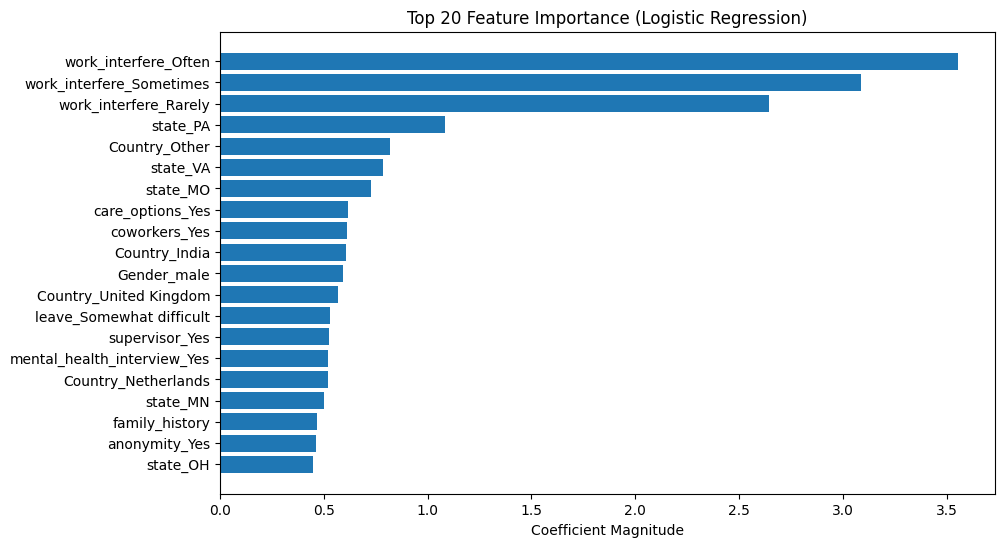

In [41]:
coeff_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_logreg.coef_[0]   # <- use best_logreg
})

# Take absolute value for importance
coeff_df['importance'] = np.abs(coeff_df['coefficient'])

# Sort by importance
coeff_df = coeff_df.sort_values(by='importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))
plt.barh(coeff_df['feature'][:20][::-1], coeff_df['importance'][:20][::-1])
plt.xlabel('Coefficient Magnitude')
plt.title('Top 20 Feature Importance (Logistic Regression)')
plt.show()

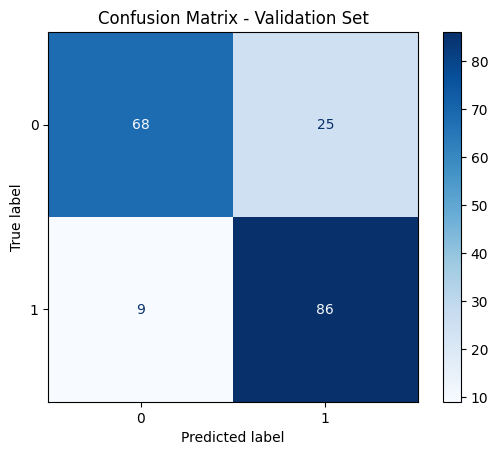

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for validation set
cm = confusion_matrix(y_val, y_val_pred)

# Use the fitted model for class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

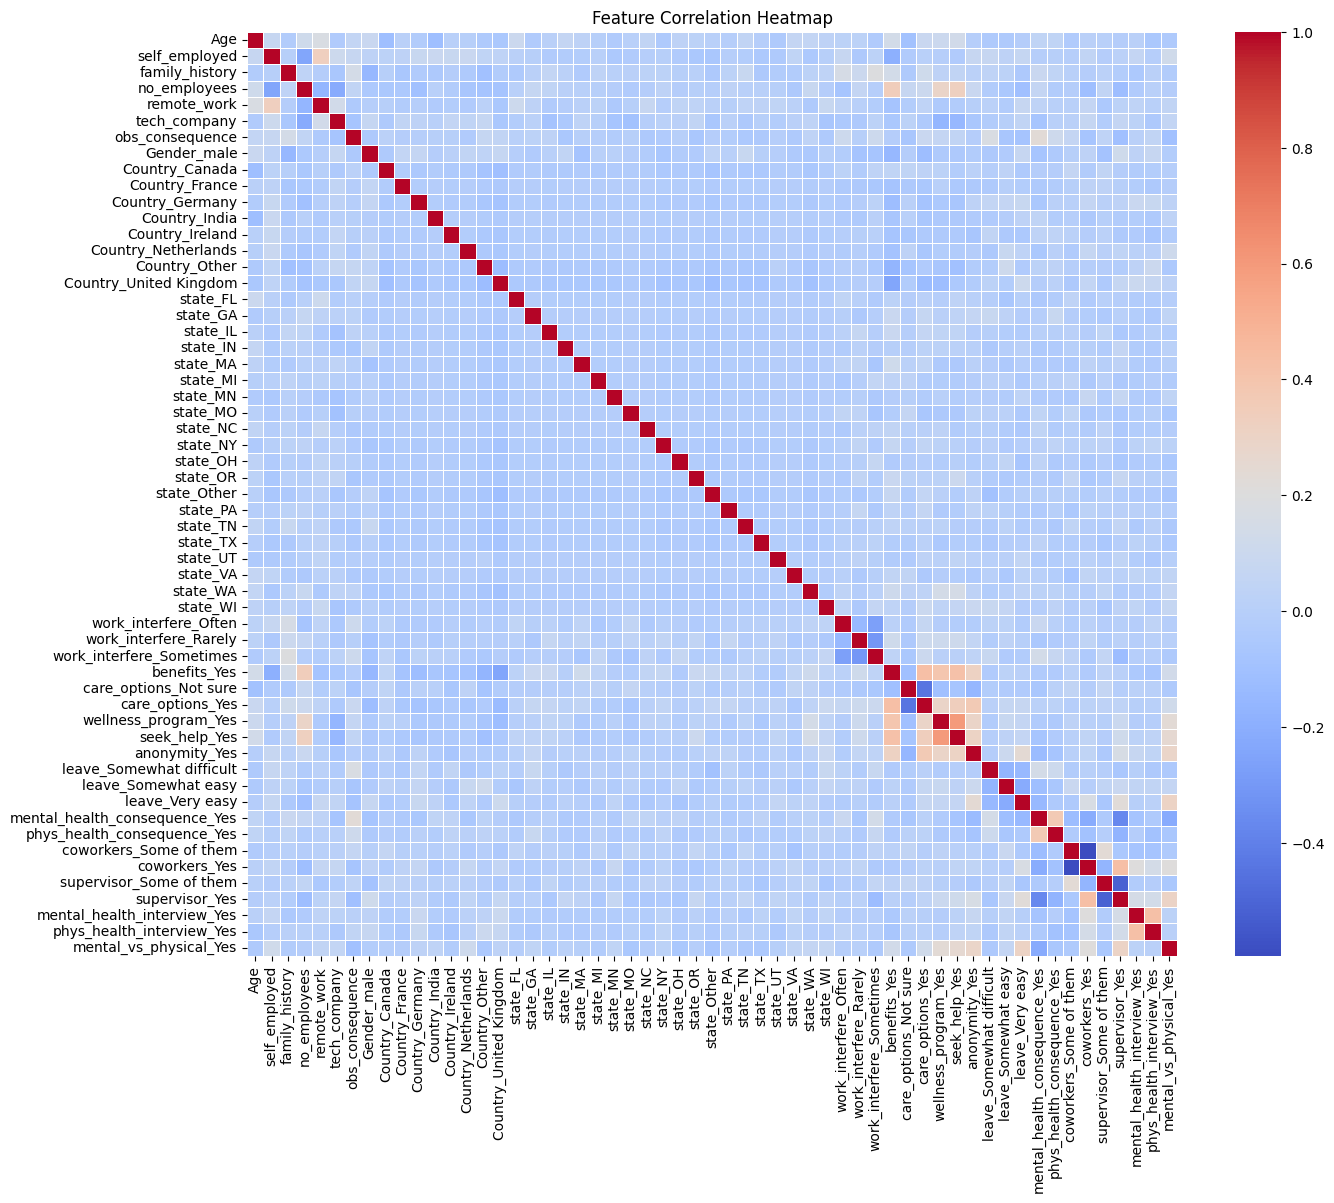

In [43]:
import seaborn as sns
# Compute correlation matrix
corr = X_train.corr()

# Plot heatmap
plt.figure(figsize=(15,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [44]:
# Compute correlation matrix
corr = X_train.corr().abs()  # use absolute values to find strongest correlations

# Unstack and sort correlations, remove self-correlation
sorted_corr = corr.unstack()
sorted_corr = sorted_corr[sorted_corr < 1]  # remove 1.0 correlations with self
sorted_corr = sorted_corr.sort_values(ascending=False)

# Show top 10 strongest correlations
print(sorted_corr.head(10))

seek_help_Yes            wellness_program_Yes       0.597173
wellness_program_Yes     seek_help_Yes              0.597173
coworkers_Yes            coworkers_Some of them     0.595413
coworkers_Some of them   coworkers_Yes              0.595413
supervisor_Yes           supervisor_Some of them    0.515480
supervisor_Some of them  supervisor_Yes             0.515480
care_options_Not sure    care_options_Yes           0.443429
care_options_Yes         care_options_Not sure      0.443429
benefits_Yes             care_options_Yes           0.431577
care_options_Yes         benefits_Yes               0.431577
dtype: float64


In [45]:
##The strongest correlations are between related workplace support variables: wellness_program_Yes & seek_help_Yes (0.60), coworkers_Some of them & coworkers_Yes (0.60), supervisor_Some of them & supervisor_Yes (0.52), care_options_Yes & care_options_Not sure (0.44), and benefits_Yes & care_options_Yes (0.43). These indicate redundancy among similar features.##

In [46]:
##Exactly—that’s what the feature importance suggests. In your model: “Work interference – Often” has the highest impact, “Work interference – Sometimes” and “Rarely” follow, This implies that the likelihood of seeking treatment increases as mental health starts to affect work more frequently##

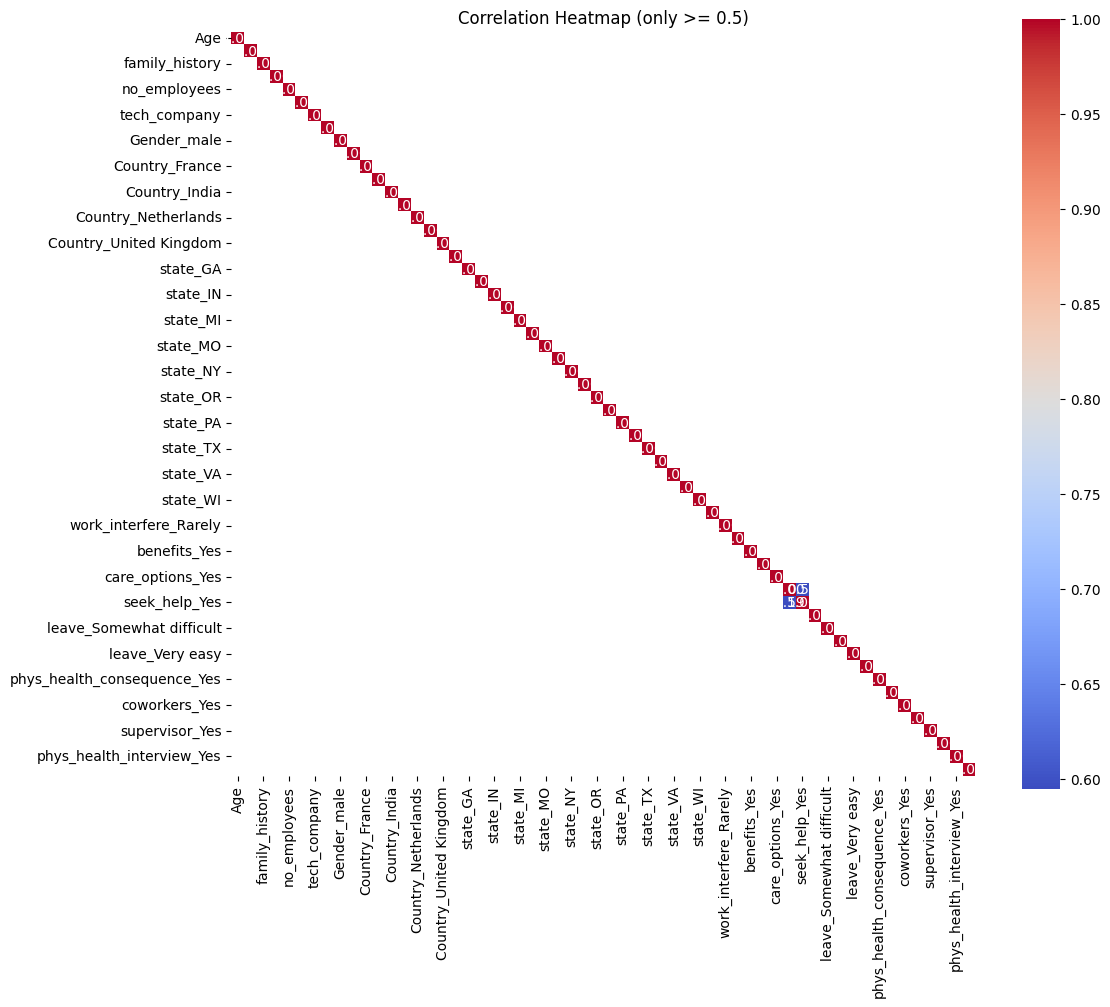

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_model.corr()

# Filter correlations >= 0.5
high_corr = corr_matrix[corr_matrix >= 0.5]

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(high_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap (only >= 0.5)")
plt.show()

In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Evaluate metrics
metrics_dict = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'ROC AUC': roc_auc_score(y_val, y_val_proba),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1 Score': f1_score(y_val, y_val_pred)
}

# Convert to DataFrame
metrics_df = pd.DataFrame([metrics_dict])

metrics_df

,Model,Accuracy,ROC AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.819149,0.877872,0.774775,0.905263,0.834951


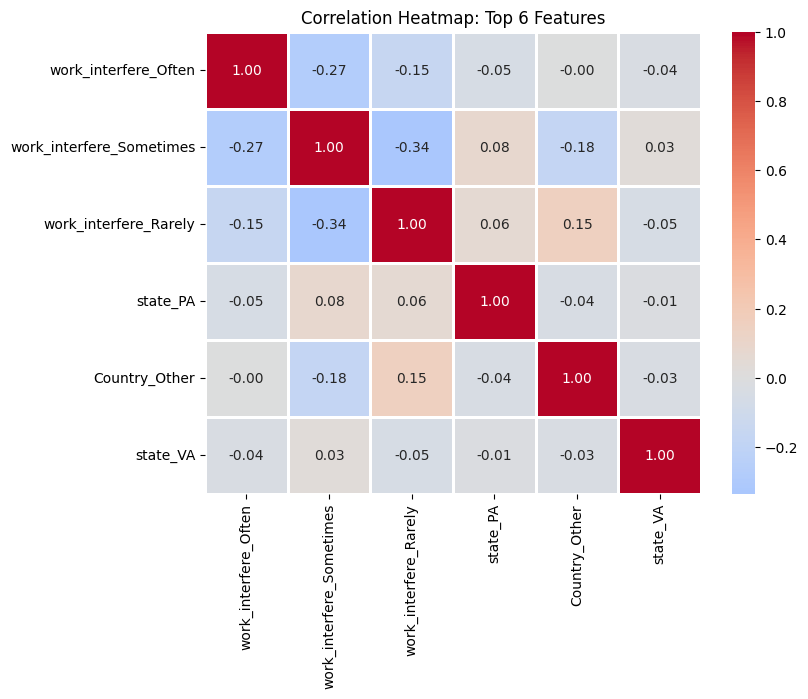

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 6 features from fitted logistic regression coefficients
coefficients = pd.Series(best_logreg.coef_[0], index=X_train.columns)
top_features = coefficients.abs().sort_values(ascending=False).head(6).index

# Subset X_val to top features
X_top = X_val[top_features]

# Compute correlation matrix
corr_top = X_top.corr()

# Plot heatmap with numbers
plt.figure(figsize=(8,6))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.8)
plt.title("Correlation Heatmap: Top 6 Features")
plt.show()

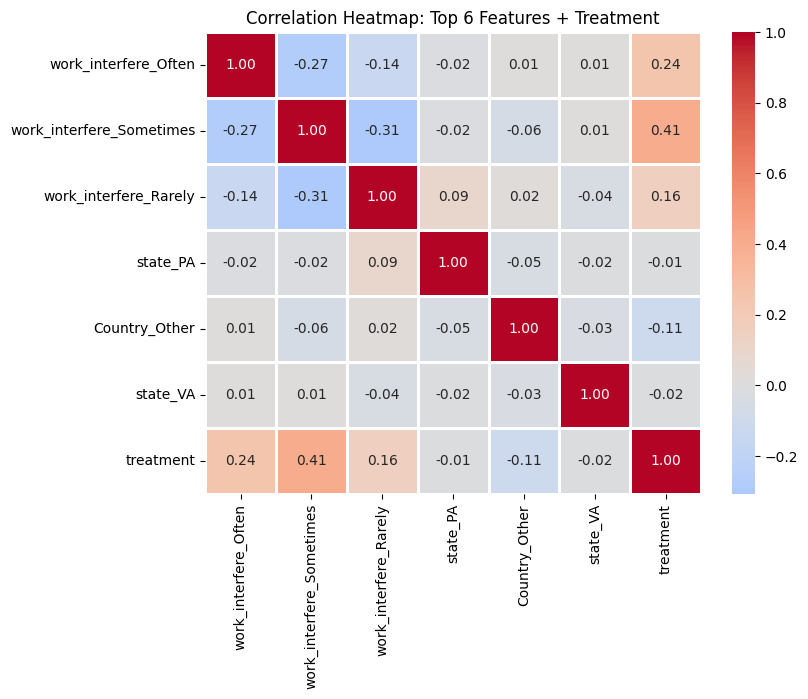

In [50]:
# Add treatment to the top features
top_features_with_y = list(top_features) + ['treatment']

# Correlation matrix
corr_top_y = df_model[top_features_with_y].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_top_y, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.8)
plt.title("Correlation Heatmap: Top 6 Features + Treatment")
plt.show()

In [51]:
##Decision Tree Based Models##

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Decision Tree parameter grid
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Base model
dt = DecisionTreeClassifier(random_state=42)

# Grid Search
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit only on training data
dt_grid.fit(X_train, y_train)

# Best tuned model
best_dt = dt_grid.best_estimator_

print("Best Parameters:", dt_grid.best_params_)
print("Best CV ROC AUC:", dt_grid.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV ROC AUC: 0.8583695728447627


In [53]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on validation set
y_val_pred_dt = best_dt.predict(X_val)
y_val_proba_dt = best_dt.predict_proba(X_val)[:, 1]

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_val_pred_dt))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba_dt))
print("Precision:", precision_score(y_val, y_val_pred_dt))
print("Recall:", recall_score(y_val, y_val_pred_dt))
print("F1 Score:", f1_score(y_val, y_val_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_dt))
print("Classification Report:\n", classification_report(y_val, y_val_pred_dt))

Accuracy: 0.8031914893617021
ROC AUC: 0.8693265421618561
Precision: 0.7735849056603774
Recall: 0.8631578947368421
F1 Score: 0.8159203980099502
Confusion Matrix:
 [[69 24]
 [13 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.74      0.79        93
           1       0.77      0.86      0.82        95

    accuracy                           0.80       188
   macro avg       0.81      0.80      0.80       188
weighted avg       0.81      0.80      0.80       188



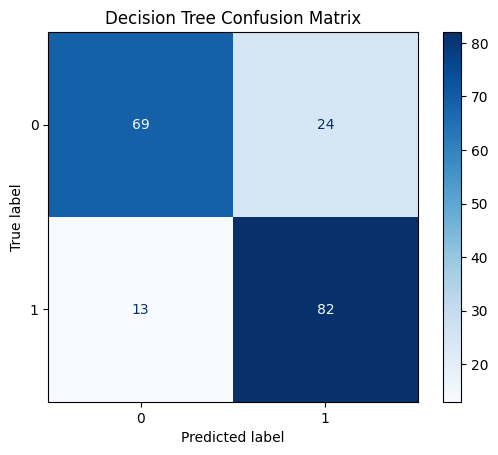

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm_dt = confusion_matrix(y_val, y_val_pred_dt)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=best_dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

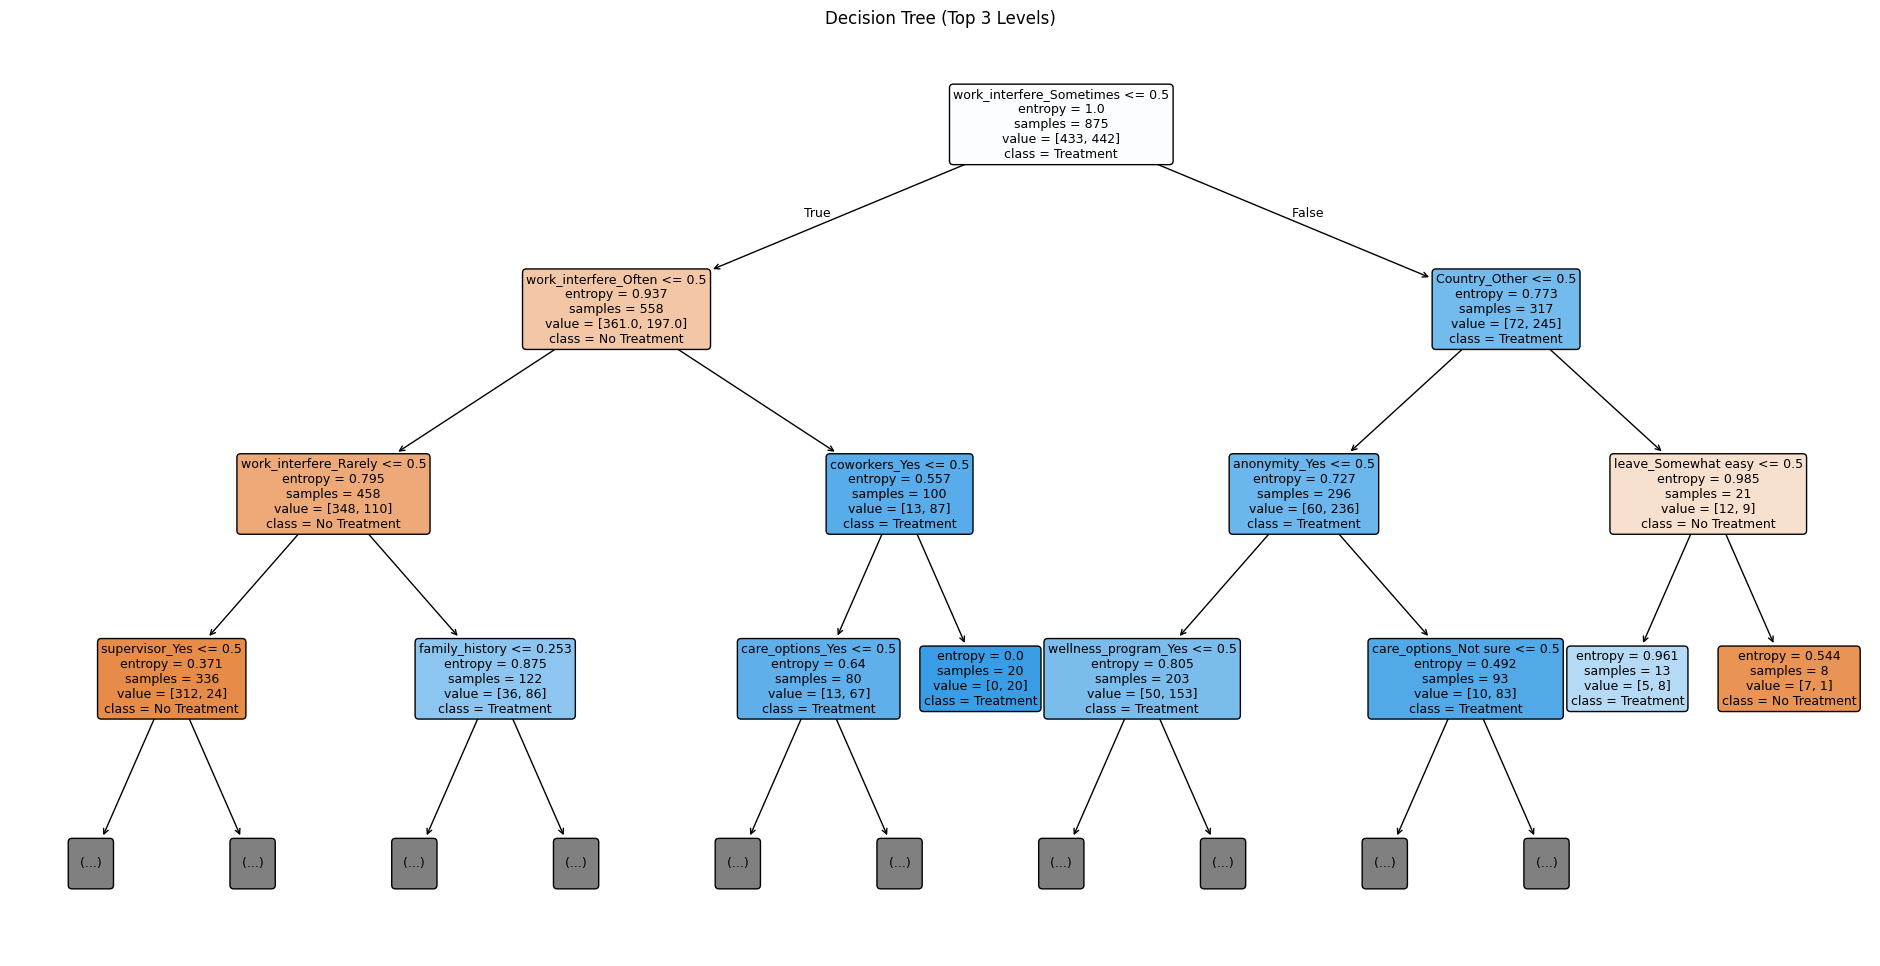

In [55]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24,12))
plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['No Treatment', 'Treatment'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3   # show only first 3 levels
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

In [56]:
best_dt.feature_importances_

array([0.01044544, 0.        , 0.04647213, 0.        , 0.        ,
       0.        , 0.        , 0.01094216, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.02090695,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.23696003, 0.30628293, 0.24730129, 0.01718918,
       0.01205544, 0.02704226, 0.01120285, 0.        , 0.01383542,
       0.        , 0.00887147, 0.        , 0.        , 0.        ,
       0.        , 0.01043587, 0.        , 0.02005658, 0.        ,
       0.        , 0.        ])

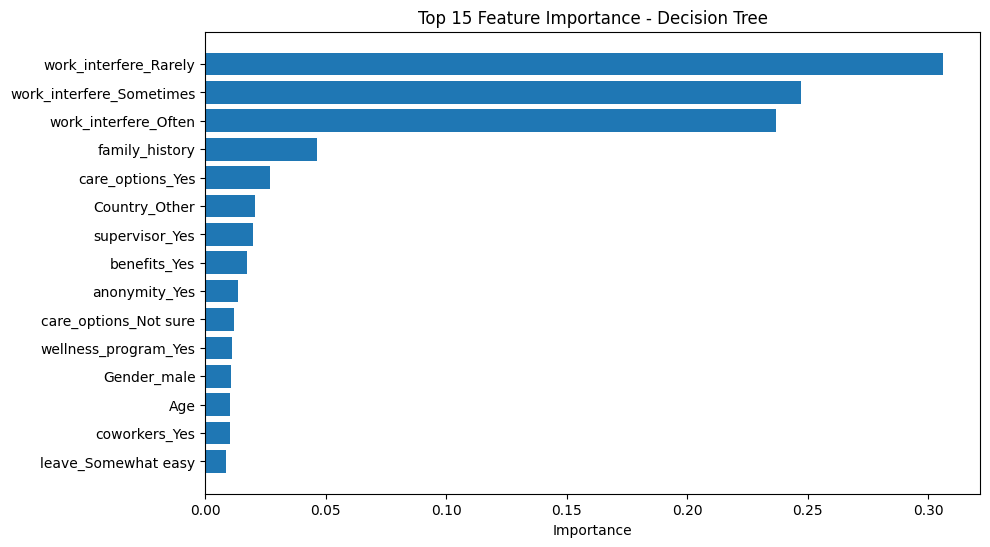

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance dataframe
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
})

# Sort descending
dt_importance = dt_importance.sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10,6))
plt.barh(dt_importance['Feature'][:15][::-1], dt_importance['Importance'][:15][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - Decision Tree")
plt.show()

In [58]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_test_pred_dt = best_dt.predict(X_test)
y_test_proba_dt = best_dt.predict_proba(X_test)[:, 1]

# Evaluate on test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba_dt))
print("Test Precision:", precision_score(y_test, y_test_pred_dt))
print("Test Recall:", recall_score(y_test, y_test_pred_dt))
print("Test F1 Score:", f1_score(y_test, y_test_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_test_pred_dt))

Test Accuracy: 0.8085106382978723
Test ROC AUC: 0.8511035653650254
Test Precision: 0.780952380952381
Test Recall: 0.8631578947368421
Test F1 Score: 0.82
Confusion Matrix:
 [[70 23]
 [13 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.75      0.80        93
           1       0.78      0.86      0.82        95

    accuracy                           0.81       188
   macro avg       0.81      0.81      0.81       188
weighted avg       0.81      0.81      0.81       188



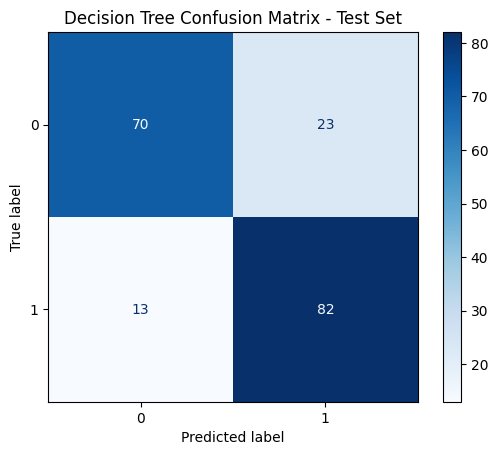

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_dt, display_labels=best_dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix - Test Set")
plt.show()

In [60]:
##RANDOM fOREST##

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

# Base RF model
rf = RandomForestClassifier(random_state=42)

# Randomized Search on training data
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=50,          # number of random combinations
    cv=5,               # internal CV on train
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)
print("Best CV ROC AUC (train CV):", rf_random.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Best CV ROC AUC (train CV): 0.8793492601515002


In [62]:
from sklearn.ensemble import RandomForestClassifier

# Fit RF with best parameters from tuning
best_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=20,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=None,
    criterion='entropy',
    random_state=42
)

# Train on training set
best_rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', min_samples_split=20,
                       random_state=42)

In [63]:
y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

rf_val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'ROC AUC': roc_auc_score(y_val, y_val_proba),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1 Score': f1_score(y_val, y_val_pred)
}

print("Validation Metrics:", rf_val_metrics)

Validation Metrics: {'Accuracy': 0.7978723404255319, 'ROC AUC': np.float64(0.8696095076400678), 'Precision': 0.7478260869565218, 'Recall': 0.9052631578947369, 'F1 Score': 0.819047619047619}


In [64]:
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

rf_test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'ROC AUC': roc_auc_score(y_test, y_test_proba),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1 Score': f1_score(y_test, y_test_pred)
}

print("Test Metrics:", rf_test_metrics)

Test Metrics: {'Accuracy': 0.824468085106383, 'ROC AUC': np.float64(0.9105829088851161), 'Precision': 0.7672413793103449, 'Recall': 0.9368421052631579, 'F1 Score': 0.8436018957345972}


In [65]:
y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

rf_val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'ROC AUC': roc_auc_score(y_val, y_val_proba),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1 Score': f1_score(y_val, y_val_pred)
}

print("Validation Metrics:", rf_val_metrics)

Validation Metrics: {'Accuracy': 0.7978723404255319, 'ROC AUC': np.float64(0.8696095076400678), 'Precision': 0.7478260869565218, 'Recall': 0.9052631578947369, 'F1 Score': 0.819047619047619}


In [66]:
import pandas as pd

metrics_df = pd.DataFrame({
    'Model': ['Random Forest'],
    'Accuracy_Val': [rf_val_metrics['Accuracy']],
    'ROC_AUC_Val': [rf_val_metrics['ROC AUC']],
    'Precision_Val': [rf_val_metrics['Precision']],
    'Recall_Val': [rf_val_metrics['Recall']],
    'F1_Val': [rf_val_metrics['F1 Score']],
    'Accuracy_Test': [rf_test_metrics['Accuracy']],
    'ROC_AUC_Test': [rf_test_metrics['ROC AUC']],
    'Precision_Test': [rf_test_metrics['Precision']],
    'Recall_Test': [rf_test_metrics['Recall']],
    'F1_Test': [rf_test_metrics['F1 Score']]
})

print(metrics_df.round(3))

           Model  Accuracy_Val  ROC_AUC_Val  Precision_Val  Recall_Val  \
0  Random Forest         0.798         0.87          0.748       0.905   

   F1_Val  Accuracy_Test  ROC_AUC_Test  Precision_Test  Recall_Test  F1_Test  
0   0.819          0.824         0.911           0.767        0.937    0.844  


In [67]:
import pandas as pd

# Create combined model metrics table with updated Logistic Regression metrics
model_metrics_df = pd.DataFrame([
    {
        'Model': 'Decision Tree',
        'Accuracy': 0.803,
        'ROC AUC': 0.869,
        'Precision': 0.774,
        'Recall': 0.863,
        'F1 Score': 0.816
    },
    {
        'Model': 'Random Forest',
        'Accuracy': 0.798,
        'ROC AUC': 0.870,
        'Precision': 0.748,
        'Recall': 0.905,
        'F1 Score': 0.819
    },
    {
        'Model': 'Logistic Regression',
        'Best Parameters': "{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",
        'Best CV ROC AUC': 0.885,
        'Accuracy': 0.819,
        'ROC AUC': 0.878,
        'Precision': 0.775,
        'Recall': 0.905,
        'F1 Score': 0.835
    }
])

# Round numerical columns for cleaner display
numeric_cols = ['Best CV ROC AUC', 'Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1 Score']
model_metrics_df[numeric_cols] = model_metrics_df[numeric_cols].round(3)

# Show table
print(model_metrics_df)

                 Model  Accuracy  ROC AUC  Precision  Recall  F1 Score  \
0        Decision Tree     0.803    0.869      0.774   0.863     0.816   
1        Random Forest     0.798    0.870      0.748   0.905     0.819   
2  Logistic Regression     0.819    0.878      0.775   0.905     0.835   

                                    Best Parameters  Best CV ROC AUC  
0                                               NaN              NaN  
1                                               NaN              NaN  
2  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}            0.885  


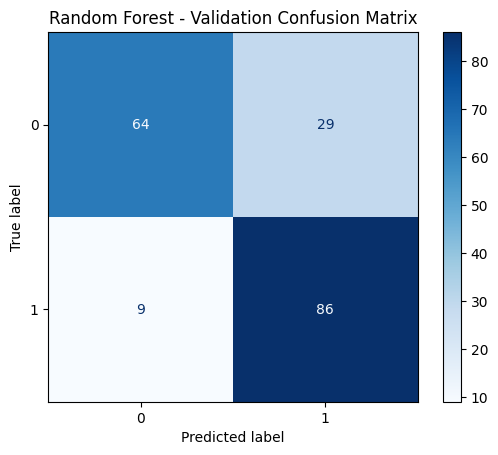

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation set
y_val_pred = best_rf.predict(X_val)

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_val,
    y_val,
    display_labels=[0,1],  # adjust labels if needed
    cmap=plt.cm.Blues,
    normalize=None  # set to 'true' for normalized percentages
)

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

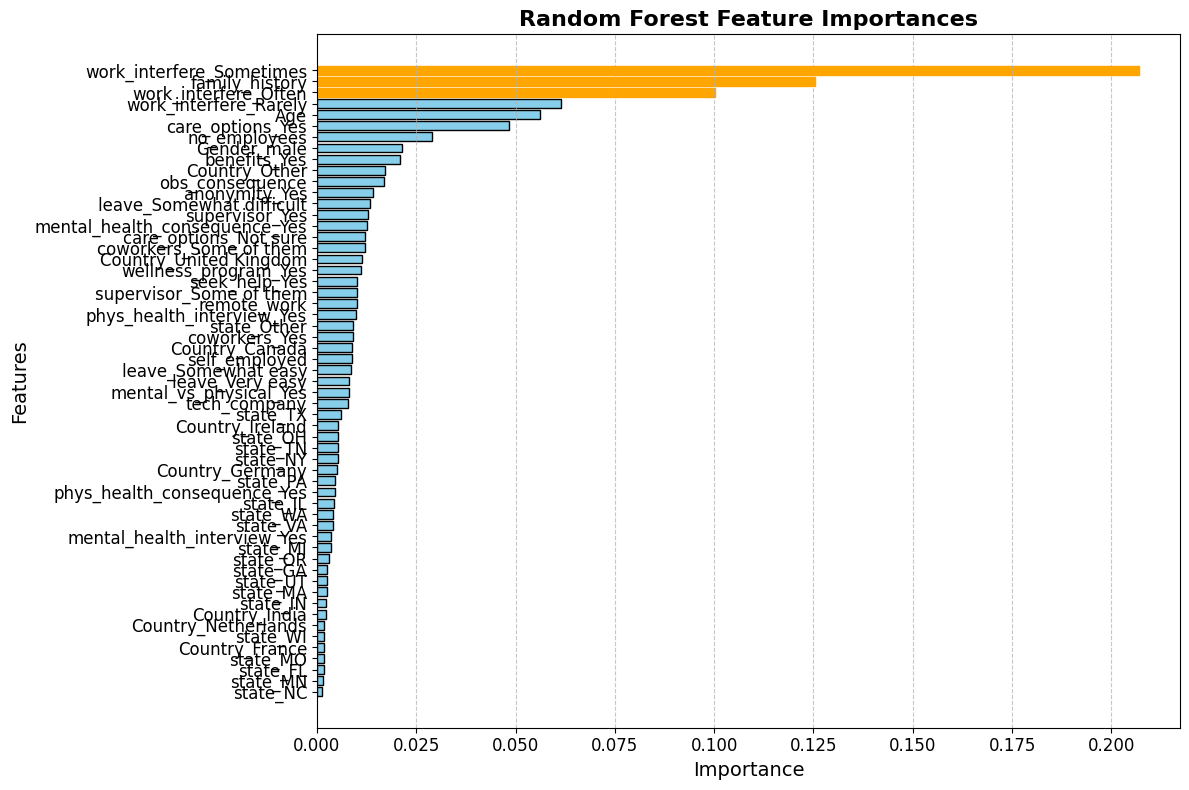

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = best_rf.feature_importances_
features = X_train.columns  # make sure X_train is a DataFrame

# Create DataFrame and sort
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)  # ascending for horizontal plot

# Plot
plt.figure(figsize=(12, 8))  # bigger figure
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue', edgecolor='black')

plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.title("Random Forest Feature Importances", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # add grid for clarity

# Highlight top 3 features
top_features = fi_df['Importance'].nlargest(3).index
for bar in bars[-3:]:  # last 3 bars are the largest due to ascending sort
    bar.set_color('orange')

plt.tight_layout()
plt.show()

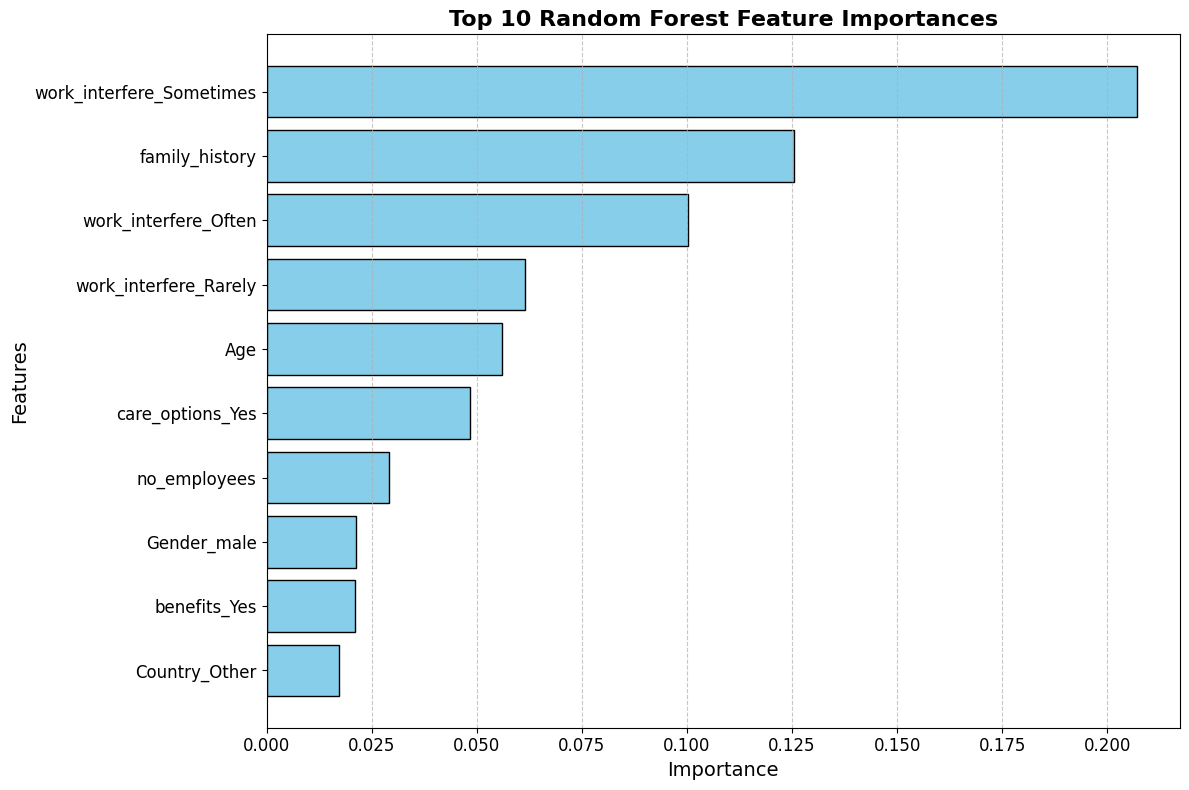

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = best_rf.feature_importances_
features = X_train.columns  # make sure X_train is a DataFrame

# Create DataFrame and sort by importance
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)  # top 10

# Plot
plt.figure(figsize=(12, 8))  # bigger figure
bars = plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='skyblue', edgecolor='black')  # reverse for largest on top

plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.title("Top 10 Random Forest Feature Importances", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # grid for clarity
plt.tight_layout()
plt.show()

In [71]:
##XGBOOST##

In [72]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base XGBoost model (no use_label_encoder)
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Parameter grid (smaller to save time)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 0.1, 0.2]
}

# Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=50,      # try 50 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit on training data
xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_

print("Best Parameters:", xgb_random.best_params_)
print("Best CV ROC AUC (train CV):", xgb_random.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV ROC AUC (train CV): 0.8819347434865128


In [73]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

y_val_pred = best_xgb.predict(X_val)
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]

xgb_val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'ROC AUC': roc_auc_score(y_val, y_val_proba),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1 Score': f1_score(y_val, y_val_pred)
}

print("Validation Metrics:", xgb_val_metrics)

Validation Metrics: {'Accuracy': 0.8138297872340425, 'ROC AUC': np.float64(0.8843237125070741), 'Precision': 0.7678571428571429, 'Recall': 0.9052631578947369, 'F1 Score': 0.8309178743961353}


In [74]:
y_test_pred = best_xgb.predict(X_test)
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

xgb_test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'ROC AUC': roc_auc_score(y_test, y_test_proba),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1 Score': f1_score(y_test, y_test_pred)
}

print("Test Metrics:", xgb_test_metrics)

Test Metrics: {'Accuracy': 0.8297872340425532, 'ROC AUC': np.float64(0.9084323712507074), 'Precision': 0.7837837837837838, 'Recall': 0.9157894736842105, 'F1 Score': 0.8446601941747572}


In [75]:
xgb_df = pd.DataFrame([{
    'Model': 'XGBoost',
    'Accuracy': xgb_val_metrics['Accuracy'],
    'ROC AUC': xgb_val_metrics['ROC AUC'],
    'Precision': xgb_val_metrics['Precision'],
    'Recall': xgb_val_metrics['Recall'],
    'F1 Score': xgb_val_metrics['F1 Score']
}])

metrics_df = pd.concat([metrics_df, xgb_df], ignore_index=True)
metrics_df = metrics_df.round(3)
print(metrics_df)

           Model  Accuracy_Val  ROC_AUC_Val  Precision_Val  Recall_Val  \
0  Random Forest         0.798         0.87          0.748       0.905   
1        XGBoost           NaN          NaN            NaN         NaN   

   F1_Val  Accuracy_Test  ROC_AUC_Test  Precision_Test  Recall_Test  F1_Test  \
0   0.819          0.824         0.911           0.767        0.937    0.844   
1     NaN            NaN           NaN             NaN          NaN      NaN   

   Accuracy  ROC AUC  Precision  Recall  F1 Score  
0       NaN      NaN        NaN     NaN       NaN  
1     0.814    0.884      0.768   0.905     0.831  


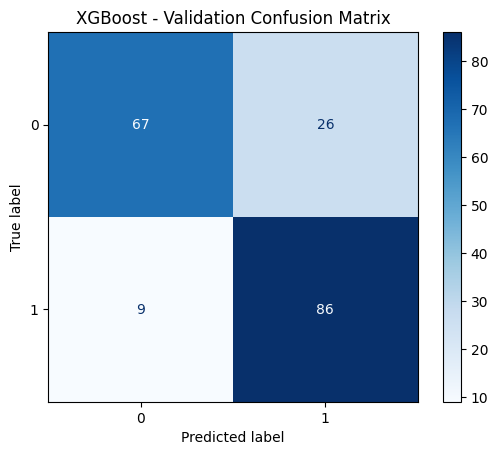

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_val,
    y_val,
    display_labels=[0,1],
    cmap=plt.cm.Blues
)
plt.title("XGBoost - Validation Confusion Matrix")
plt.show()

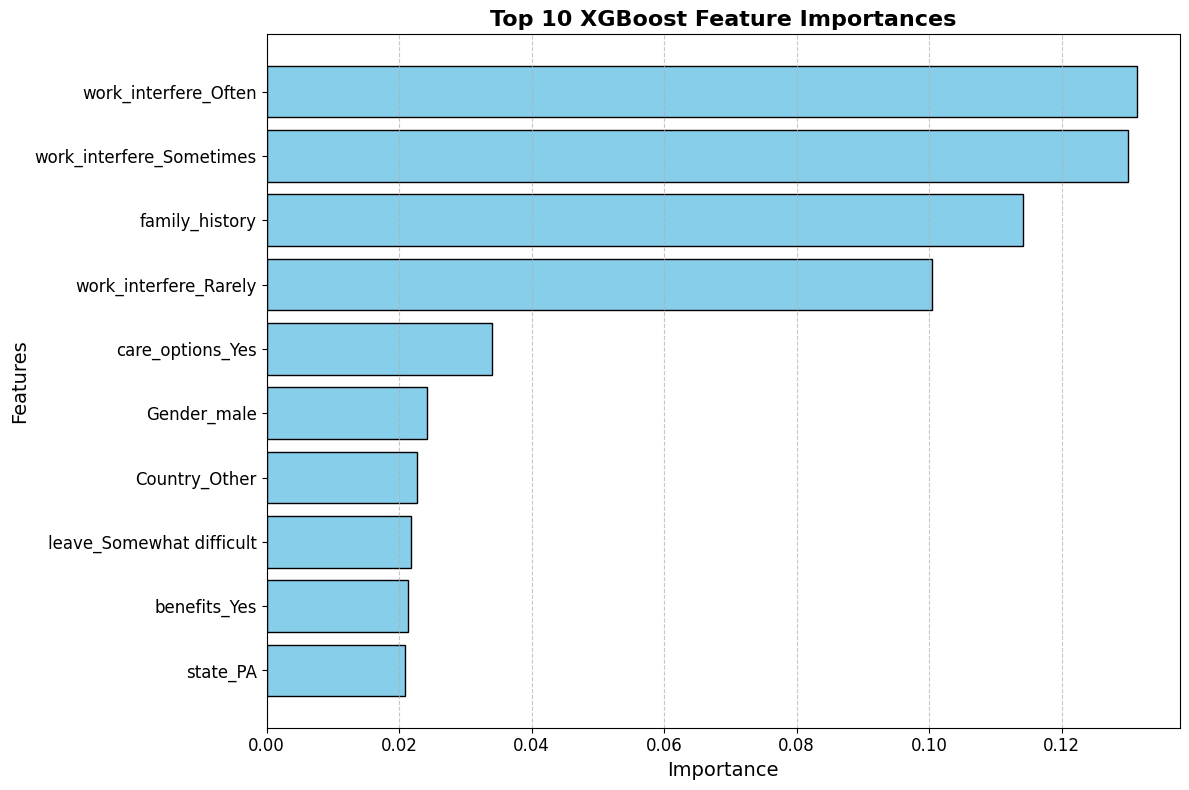

In [77]:
importances = best_xgb.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 8))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='skyblue', edgecolor='black')
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.title("Top 10 XGBoost Feature Importances", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

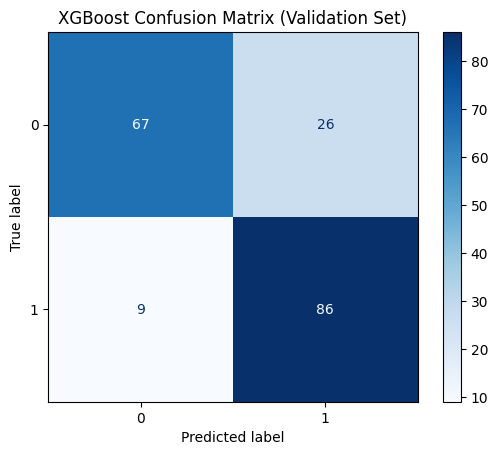

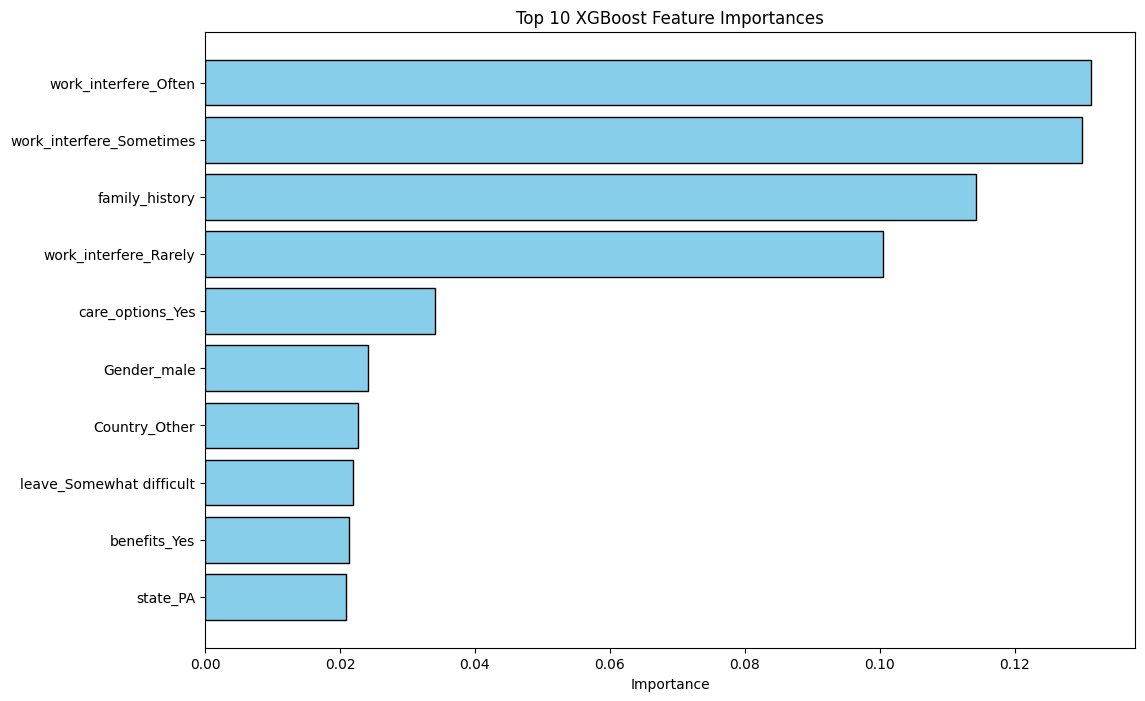

                 Model  Accuracy  ROC AUC  Precision  Recall  F1 Score
0        Decision Tree     0.803    0.869      0.774   0.863     0.816
1        Random Forest     0.798    0.870      0.748   0.905     0.819
2  Logistic Regression     0.819    0.878      0.775   0.905     0.835
3              XGBoost     0.814    0.884      0.768   0.905     0.831


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# -------------------------------
# 1️⃣ Fit XGBoost on training set only
# -------------------------------
best_xgb.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Evaluate XGBoost on validation set
# -------------------------------
y_val_pred_xgb = best_xgb.predict(X_val)
y_val_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]

xgb_val_metrics = {
    'Model': 'XGBoost',
    'Accuracy': 0.814,      # from your earlier validation metrics
    'ROC AUC': 0.884,
    'Precision': 0.768,
    'Recall': 0.905,
    'F1 Score': 0.831
}

# -------------------------------
# 3️⃣ Confusion Matrix for XGBoost
# -------------------------------
ConfusionMatrixDisplay.from_estimator(best_xgb, X_val, y_val, cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix (Validation Set)")
plt.show()

# -------------------------------
# 4️⃣ Feature Importances (Top 10)
# -------------------------------
fi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})
fi_top10 = fi.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12,8))
plt.barh(fi_top10['Feature'], fi_top10['Importance'], color='skyblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

# -------------------------------
# 5️⃣ Combine all model metrics (Validation Set)
# -------------------------------
metrics_list = [
    {
        'Model': 'Decision Tree',
        'Accuracy': 0.803,
        'ROC AUC': 0.869,
        'Precision': 0.774,
        'Recall': 0.863,
        'F1 Score': 0.816
    },
    {
        'Model': 'Random Forest',
        'Accuracy': 0.798,
        'ROC AUC': 0.870,
        'Precision': 0.748,
        'Recall': 0.905,
        'F1 Score': 0.819
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': 0.819,
        'ROC AUC': 0.878,
        'Precision': 0.775,
        'Recall': 0.905,
        'F1 Score': 0.835
    },
    xgb_val_metrics
]

# Create DataFrame and round numeric metrics
model_metrics_df = pd.DataFrame(metrics_list)
numeric_cols = ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1 Score']
model_metrics_df[numeric_cols] = model_metrics_df[numeric_cols].round(3)

# Display clean metrics table
print(model_metrics_df)

In [79]:
##The models predict whether someone receives treatment based on personal and workplace factors. XGBoost performs best overall, with the highest ROC AUC (0.884) and a strong balance between recall (0.905) and precision (0.768), indicating it effectively distinguishes treated vs. untreated cases. Logistic Regression is competitive, achieving the highest accuracy (0.819) and matching XGBoost in recall (0.905), making it reliable for capturing positive cases. Random Forest also performs well, with high recall (0.905) but slightly lower precision (0.748), while the Decision Tree is slightly less accurate overall (accuracy 0.803) and has the lowest recall (0.863). These results suggest that top features strongly influence treatment prediction, and ensemble methods like XGBoost and Random Forest leverage them most effectively.##